In [1]:
import tensorflow as tf
import numpy as np
from PIL import Image

In [2]:
# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Create Model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),
    tf.keras.layers.Dense(
        10,
        activation='softmax'
    ),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# Train Model
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8579 - loss: 2.4135
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9094 - loss: 0.3766
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9316 - loss: 0.2726
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9401 - loss: 0.2465
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9465 - loss: 0.2228


In [6]:
# Test Accuracy
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("Test Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9461 - loss: 0.2520
Test Accuracy:  0.9460999965667725


In [7]:
# ==============================
# User Image Prediction
# ==============================
img = Image.open("7.png")
# Convert to grayscale
img = img.convert('L')
# Resize
img = img.resize((28, 28))
# Convert image
img = np.array(img)
# Prediction
img = img.reshape(1, 28, 28)
prediction = model.predict(img)
digit = np.argmax(prediction)
print("Prediction: ", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
PredictionL  3


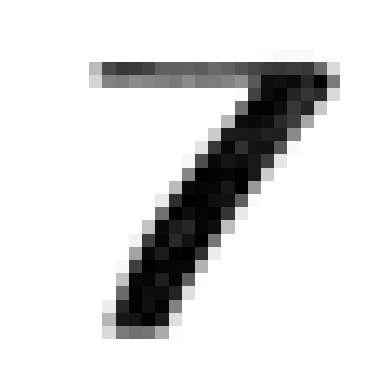

In [8]:
import matplotlib.pyplot as plt
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()